# Figure 3: Zero-shot results

Plots zero-shot evaluation (L2 distance) for the core CochCNN9 models at `relu4`.
Loads CSVs from `results_dfs/` produced by the zero-shot eval scripts.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
import sys

sys.path.insert(0, str(Path("../").resolve()))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    set_bar_labels,
    plot_sequential_bars,
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
%matplotlib inline

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)


## Load zero-shot result CSVs

In [2]:
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lightning_scripts").is_dir():
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "results_dfs"

TASK_FILES = {
    "Loudness order discrimination": [
        "zero_shot_speech_commands_cochdnn_layerwise.csv",
        "zero_shot_speech_commands_byola_layerwise.csv",
    ],
    "Melody match": [
        "zero_shot_nsynth_cochdnn_layerwise.csv",
        "zero_shot_nsynth_byola_layerwise.csv",
    ],
    "Mandarin tone discrimination": [
        "zero_shot_mandarin_cochdnn_layerwise.csv",
        "zero_shot_mandarin_byola_layerwise.csv",
    ],
}

dfs = []
for task, filenames in TASK_FILES.items():
    for filename in filenames:
        path = RESULTS_DIR / filename
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df["task"] = task
        dfs.append(df)

if not dfs:
    raise FileNotFoundError(
        f"No zero-shot layerwise CSVs found in {RESULTS_DIR.resolve()}. "
        "Run eval_layerwise_zero_shot.py --gather for cochdnn and byola."
    )

results_df = pd.concat(dfs, ignore_index=True)
results_df["model_name"] = results_df["model_name"].astype(str).str.replace("DNN", "CNN")
no_byola_df = results_df[results_df["model_name"] != "byol-a"].copy()


## Core models

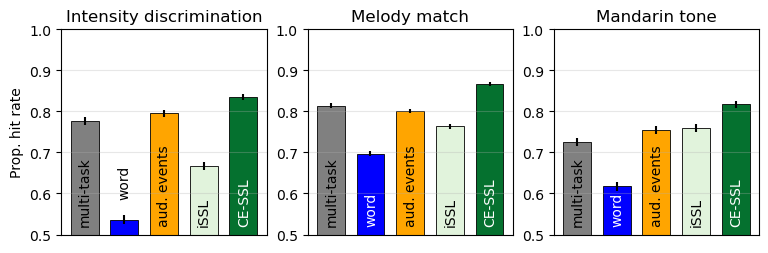

In [3]:
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


main_plot_models = [
    "CochCNN9 supervised multi-task",
    "CochCNN9 supervised word",
    "CochCNN9 supervised audioset",
    "CochCNN9 ssl λ=0.0",
    "CochCNN9 ssl λ=0.5",
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
hue_dict = build_model_palette(hue_order, get_standard_base_colors())


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


layers = ["relu4"]
n_rows, n_cols = len(layers), len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * n_cols, base_size * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        task_title = task_name.replace(" discrimination", "")
        if task_title == "Loudness order":
            task_title = "Intensity discrimination"
        ylabel = "Prop. hit rate" if col_idx == 0 else ""

        if not plot_df.empty:
            plot_sequential_bars(
                ax,
                plot_df,
                value_col,
                task_title,
                ylabel,
                xlabel="",
                hue_order=hue_order,
                hue_dict=hue_dict,
                error_type="sem",
                capsize=0,
            )

        ax.set_title(task_title)
        ax.set_ylim(0.5, 1.0)
        if col_idx > 0:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.set_xticks([])
        if col_idx == 0:
            ax.set_ylabel("Prop. hit rate")

        bars = [c for c in ax.containers if isinstance(c, BarContainer)]
        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True).replace("supervised ", "")
            white_text_substrs = ["CE", "byol"] if "Loudness" in task_name else ["word", "CE", "byol"]
            set_bar_labels(
                ax,
                bar,
                [bar_label],
                white_text_substrs=white_text_substrs,
                y_cut_for_olap=0.6,
                ymin_bars=0.52,
                no_olap_pad=0.05,
                fontsize=10,
                x_shift_size=0.0125,
            )

for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright - xleft) / (ybottom - ytop)))

# plt.savefig(fig_out_dir / "zero_shot_core_models_l2.pdf", bbox_inches="tight")
